# Función candidata de Lyapunov para un sistema tipo Liénard

*(Traducción a Python del livescript `liennnard.mlx`, usando `sympy`, `numpy` y `matplotlib`)*

Definimos el sistema:

$$\dot x_1 = -x_1^2 + \frac{1}{x_2}, \qquad \dot x_2 = \frac{x_1}{x_2} - 1$$

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()

In [2]:
x1, x2 = sp.symbols('x1 x2', real=True)

f = sp.Matrix([
    -x1**2 + 1/x2,
    x1/x2 - 1
])
f

⎡    2   1 ⎤
⎢- x₁  + ──⎥
⎢        x₂⎥
⎢          ⎥
⎢  x₁      ⎥
⎢  ── - 1  ⎥
⎣  x₂      ⎦

Proponemos una función candidata de Lyapunov,

$$V = \frac{x_2-1}{x_2^2}x_1^2$$

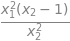

In [3]:
V = (x2 - 1) / x2**2 * x1**2
V

Calculamos el gradiente de $V$ y la derivada de Lie $\dot V = \nabla V \cdot f$, igual que en el notebook de Lyapunov del péndulo: `sympy` no tiene una función `gradient` de propósito general aquí, así que la construimos derivando respecto a cada variable.

In [4]:
gv = sp.Matrix([sp.diff(V, x1), sp.diff(V, x2)])
gv

⎡   2⋅x₁⋅(x₂ - 1)    ⎤
⎢   ─────────────    ⎥
⎢          2         ⎥
⎢        x₂          ⎥
⎢                    ⎥
⎢  2       2         ⎥
⎢x₁    2⋅x₁ ⋅(x₂ - 1)⎥
⎢─── - ──────────────⎥
⎢  2          3      ⎥
⎣x₂         x₂       ⎦

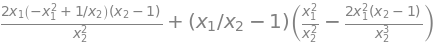

In [5]:
dotV = (gv.T * f)[0, 0]
dotV

Expandimos y simplificamos, igual que hace `expand`/`simplify` de MATLAB,

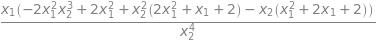

In [6]:
dotV = sp.expand(dotV)
dotV = sp.simplify(dotV)
dotV

## Visualización

Construimos una malla de puntos para representar una superficie relacionada con el problema.

In [7]:
x2n = np.arange(0, 5 + 0.01, 0.01)
x1n = x2n.copy()

x1m, x2m = np.meshgrid(x1n, x2n)

**Nota importante:** el `.mlx` original calcula

```matlab
z = (x2m.^2/2+x1m.^2/2-1).*log(x2n/2+x1n/2)
```

es decir, dentro del `log(...)` usa los vectores 1D `x2n`/`x1n` (no las mallas `x2m`/`x1m`), y MATLAB expande implícitamente ese vector fila contra cada columna de la matriz (broadcasting), en vez de tomar el valor de la malla punto a punto. **Esto es muy probablemente un descuido** en el original — la intención más natural sería `log(x2m/2+x1m/2)` — pero como no podemos estar seguros de la intención, replicamos primero la versión literal (que reproduce el mismo resultado que en MATLAB, incluyendo que la primera fila diverge a $\pm\infty$, porque en $x_1=x_2=0$ el logaritmo se anula), y dejamos también la alternativa "corregida" para que decidas cuál usar con tus estudiantes.

In [8]:
with np.errstate(divide='ignore', invalid='ignore'):
    z_literal = (x2m**2/2 + x1m**2/2 - 1) * np.log(x2n/2 + x1n/2)   # traduccion literal

print('valores finitos:', np.sum(np.isfinite(z_literal)), 'de', z_literal.size)

valores finitos: 250500 de 251001


/usr/local/lib/python3.12/dist-packages/mpl_toolkits/mplot3d/proj3d.py:135: RuntimeWarning: invalid value encountered in dot
  vecw = np.dot(M, vec.data)
/usr/local/lib/python3.12/dist-packages/mpl_toolkits/mplot3d/proj3d.py:137: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w


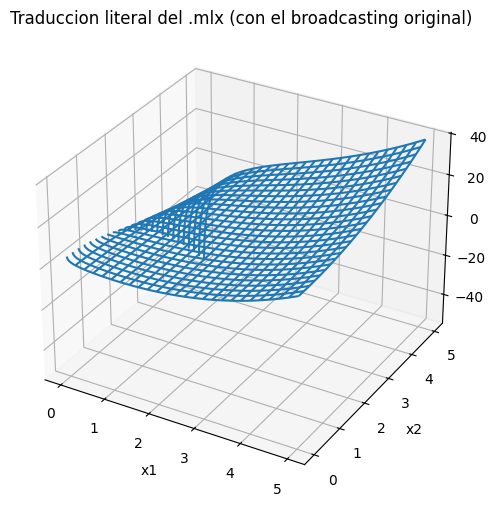

In [9]:
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.plot_wireframe(x1m, x2m, z_literal, rstride=20, cstride=20)   # 'mesh' de MATLAB
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('z')
ax.set_title('Traduccion literal del .mlx (con el broadcasting original)')
plt.show()

Y aquí la alternativa "corregida", usando `x2m`/`x1m` (la malla completa) dentro del logaritmo, en vez de los vectores 1D originales:

In [10]:
with np.errstate(divide='ignore', invalid='ignore'):
    z_malla = (x2m**2/2 + x1m**2/2 - 1) * np.log(x2m/2 + x1m/2)

print('valores finitos:', np.sum(np.isfinite(z_malla)), 'de', z_malla.size)

valores finitos: 251000 de 251001


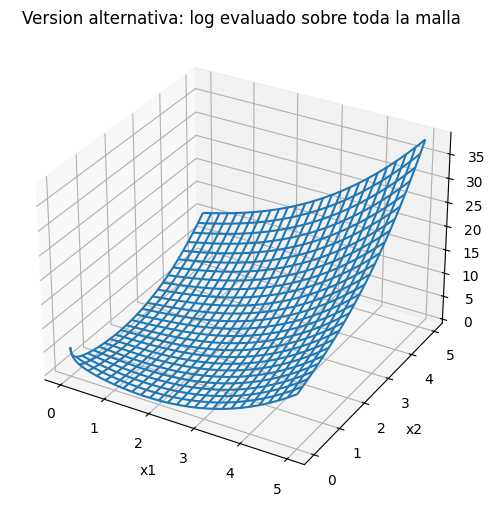

In [11]:
fig = plt.figure(2, figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.plot_wireframe(x1m, x2m, z_malla, rstride=20, cstride=20)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('z')
ax.set_title('Version alternativa: log evaluado sobre toda la malla')
plt.show()

Las dos superficies son visiblemente distintas — confirma que el uso de los vectores 1D en vez de la malla completa no es un detalle menor, cambia la forma de la superficie resultante, no solo el valor en un par de puntos aislados.